# Neural Net Code | CogSci 131 - Spring 2026
Moving from a perceptron to a neural net is a matter of judging outputs on a metric between 0 and 1. *If* the activation of a neuron is necessary for a "correct" output, *then* adjust the weights leading to that neuron from the input(s) to stimulate activation.

In [165]:
# Install Dependencies (You may need to restart after this process is complete)
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Part 1 - Basic Neural Net Structure
The code below aims to display how a neural net (physically) works through code and how we can initiate "learning" with said neural net.

In [166]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


class Neural_Network(object):
    def __init__(self):
        # Neural Net Structure Parameters
        self.inputLayerSize  = 2
        self.hiddenLayerSize = 3
        self.outputLayerSize = 1
        
        # Weight Matricies
        self.W1 = np.random.rand(self.inputLayerSize, self.hiddenLayerSize)
        self.W2 = np.random.rand(self.hiddenLayerSize, self.outputLayerSize)
        
    def forward(self, X):
        # Propogate inputs through network
        self.z2 = np.dot(X, self.W1)        #Input * Weight(s)
        self.a2 = self.sigmoid(self.z2) #See if Input * Weight(s) activates next node
        self.z3 = np.dot(self.a2, self.W2)  #Activation (of z2) * Weight(s)
        yHat = self.sigmoid(self.z3)    #See if z2 * Weight(s) activates output
        return yHat
    
    # Sigmoid for Binary Classification or Bounded Output Ranges (0 to 1)
    def sigmoid(self, z):
        # Apply Sigmoid Activation Function
        return 1 / (1 + np.exp(-z)) # 1 / (1 + e^(-z))
    
    def sigmoidPrime(self, z):
        # Derivative of Sigmoid Function
        return (np.exp(-z)) / ((1 + np.exp(-z))**2) # (e^(-z)) / ((1 + e^(-z))^2)
    
    # ReLU (Rectified Linear Unit) returns input and avoids "vanishing gradient problem"
    def relu(self, z):
        # Returns input value if positive (0 if negative)
        return np.maximum(0, z)
    
    def reluPrime(self, z):
        # Returns 
        return 1 * (z > 0) # 0 if (z <= 0); z if (z > 0)
    
    def costFunction(self, X, y):
        # Compute Cost Function with weights stored in class
        self.yHat = self.forward(X)
        J = 0.5 * np.sum((y - self.yHat)**2) # 1/2 * E((y - yHat)^2)
        return J
    
    def costFunctionPrime(self, X, y):
        # Compute derivatives with respect to W1 and W2
        self.yHat = self.forward(X)
        d3 = np.multiply(-(y - self.yHat), self.sigmoidPrime(self.z3))
        dJdW2 = np.dot(self.a2.T, d3) # .T transposes a NumPy matrix (to be properly multiplied)
        d2 = np.dot(d3, self.W2.T) * self.sigmoidPrime(self.z2)
        dJdW1 = np.dot(X.T, d2)
        return dJdW1, dJdW2
    
    def plot(self, cost):
        plt.plot(cost, linewidth=2)

        plt.title('Cost vs. Iteration')
        plt.xlabel('Iteration')
        plt.ylabel('Cost')

        plt.show()
    
    
    # Helper functions for interacting with other methods/classes
    
    def getParams(self):
        # Get W1 and W2 rolled into a vector
        params = np.concatenate((self.W1.ravel(), self.W2.ravel()))
        return params
    
    def setParams(self, params):
        params = np.asarray(params).ravel()
        
        W1_start = 0
        W1_end = self.inputLayerSize * self.hiddenLayerSize
        self.W1 = np.reshape(
            params[W1_start:W1_end],
            (self.inputLayerSize, self.hiddenLayerSize)
        )
        
        W2_end = W1_end + (self.hiddenLayerSize * self.outputLayerSize)
        self.W2 = np.reshape(
            params[W1_end:W2_end],
            (self.hiddenLayerSize, self.outputLayerSize)
        )
    
    def computeGradients(self, X, y):
        dJdW1, dJdW2 = self.costFunctionPrime(X, y)
        return np.concatenate((dJdW1.ravel(), dJdW2.ravel()))
    
    def computeNumericalGradient(N, X, y):
        paramsInitial = N.getParams().ravel()
        numgrad = np.zeros(paramsInitial.shape)  # 
        perturb = np.zeros(paramsInitial.shape)
        e = 1e-4
        
        for p in range(paramsInitial.size):
            # Set perturbation vector
            perturb[p] = e
            
            N.setParams(paramsInitial + perturb)
            loss2 = N.costFunction(X, y)
            
            N.setParams(paramsInitial - perturb)
            loss1 = N.costFunction(X, y)
            
            # Compute Numerical Gradient using perturbations to extract slope at some point
            numgrad[p] = (loss2 - loss1) / (2*e)
            
            # Revert the changed value to zero
            perturb[p] = 0.0
            
        # Return Params to original values
        N.setParams(paramsInitial)
        
        return numgrad  # Collection of numerical gradients for whole Neural Net

### Values of Vars in NN

#### Initial Values
Instantiate the training set from which to solve. The given data is asking what score someone is likely to get with x1 *Hours of Sleep* and x2 *Hours of Study* mapped to some y *Test Score*.

**Goal**

Generate a yHat (Test Score), given x1 (Sleep) and x2 (Study), that is as close to as accurate as possible. Train the NN with test data by adjusting weights such that they generate yHat values that most closely align with y (real world) via costFunctionPrime and weight adjustment. Use the newly trained model to predict test scores with novel x1 and x2.

In [167]:
X=np.array(([3,5],[5,1],[10,1]),dtype=float)  # (Hours of Sleep, Hours of Study)
y=np.array(([75],[80],[93]),dtype=float)  # Score on Test (maps to X)

X = X/np.amax(X, axis=0)  # Return the maximum of an array (along an axis)
y = y/100  # Convert score to percentage (75 -> 0.75)

X,y

(array([[0.3, 1. ],
        [0.5, 0.2],
        [1. , 0.2]]),
 array([[0.75],
        [0.8 ],
        [0.93]]))

### Plotting the cost function

In [173]:
NN = Neural_Network()
cost = []

"Training" (populate cost array to show progress)
- First code: Training and Reversion
  - Show how the sign affects directionality (in relation to cost function)
- Second code: High Scalar
  - Show how a high scalar impacts results
- Third code: Low Scalar
  - Show how a low scalar impacts results

In [174]:
scalar = 0.1
for i in range(1000):
    dJdW1,dJdW2 = NN.costFunctionPrime(X, y)
    if i < 500:
        NN.W1 = NN.W1 - scalar*dJdW1
        NN.W2 = NN.W2 - scalar*dJdW2
    else:
        NN.W1 = NN.W1 + scalar*dJdW1
        NN.W2 = NN.W2 + scalar*dJdW2
    cost.append(NN.costFunction(X,y))

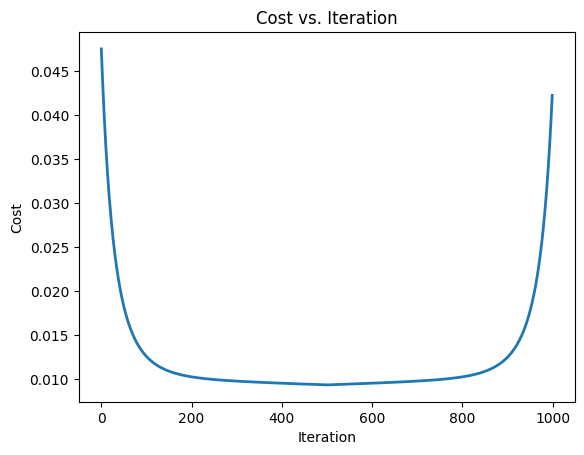

In [175]:
NN.plot(cost)